In [12]:
# Qiskit imports
from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    ClassicalRegister,
)
 
# Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
 
service = QiskitRuntimeService()

In [25]:
num_qubits = 5
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=num_qubits,
    dynamic_circuits=True,
)

In [26]:
qreg_data = QuantumRegister(3)
qreg_measure = QuantumRegister(2)
creg_data = ClassicalRegister(3, name="data")
creg_syndrome = ClassicalRegister(2, name="syndrome")
state_data = qreg_data[0]
ancillas_data = qreg_data[1:]
 
 
def build_qc():
    """Build a typical error correction circuit"""
    return QuantumCircuit(qreg_data, qreg_measure, creg_data, creg_syndrome)
 
 
def initialize_qubits(circuit: QuantumCircuit):
    """Initialize qubit to |1>"""
    circuit.x(qreg_data[0])
    circuit.barrier(qreg_data)
    return circuit
 
 
def encode_bit_flip(circuit, state, ancillas) -> QuantumCircuit:
    """Encode bit-flip. This is done by simply adding a cx"""
    for ancilla in ancillas:
        circuit.cx(state, ancilla)
    circuit.barrier(state, *ancillas)
    return circuit
 
 
def measure_syndrome_bit(circuit, qreg_data, qreg_measure, creg_measure):
    """
    Measure the syndrome by measuring the parity.
    We reset our ancilla qubits after measuring the stabilizer
    so we can reuse them for repeated stabilizer measurements.
    Because we have already observed the state of the qubit,
    we can write the conditional reset protocol directly to
    avoid another round of qubit measurement if we used
    the `reset` instruction.
    """
    circuit.cx(qreg_data[0], qreg_measure[0])
    circuit.cx(qreg_data[1], qreg_measure[0])
    circuit.cx(qreg_data[0], qreg_measure[1])
    circuit.cx(qreg_data[2], qreg_measure[1])
    circuit.barrier(*qreg_data, *qreg_measure)
    circuit.measure(qreg_measure, creg_measure)
    with circuit.if_test((creg_measure[0], 1)):
        circuit.x(qreg_measure[0])
    with circuit.if_test((creg_measure[1], 1)):
        circuit.x(qreg_measure[1])
    circuit.barrier(*qreg_data, *qreg_measure)
    return circuit
 
 
def apply_correction_bit(circuit, qreg_data, creg_syndrome):
    """We can detect where an error occurred and correct our state"""
    with circuit.if_test((creg_syndrome, 3)):
        circuit.x(qreg_data[0])
    with circuit.if_test((creg_syndrome, 1)):
        circuit.x(qreg_data[1])
    with circuit.if_test((creg_syndrome, 2)):
        circuit.x(qreg_data[2])
    circuit.barrier(qreg_data)
    return circuit
 
 
def apply_final_readout(circuit, qreg_data, creg_data):
    """Read out the final measurements"""
    circuit.barrier(qreg_data)
    circuit.measure(qreg_data, creg_data)
    return circuit

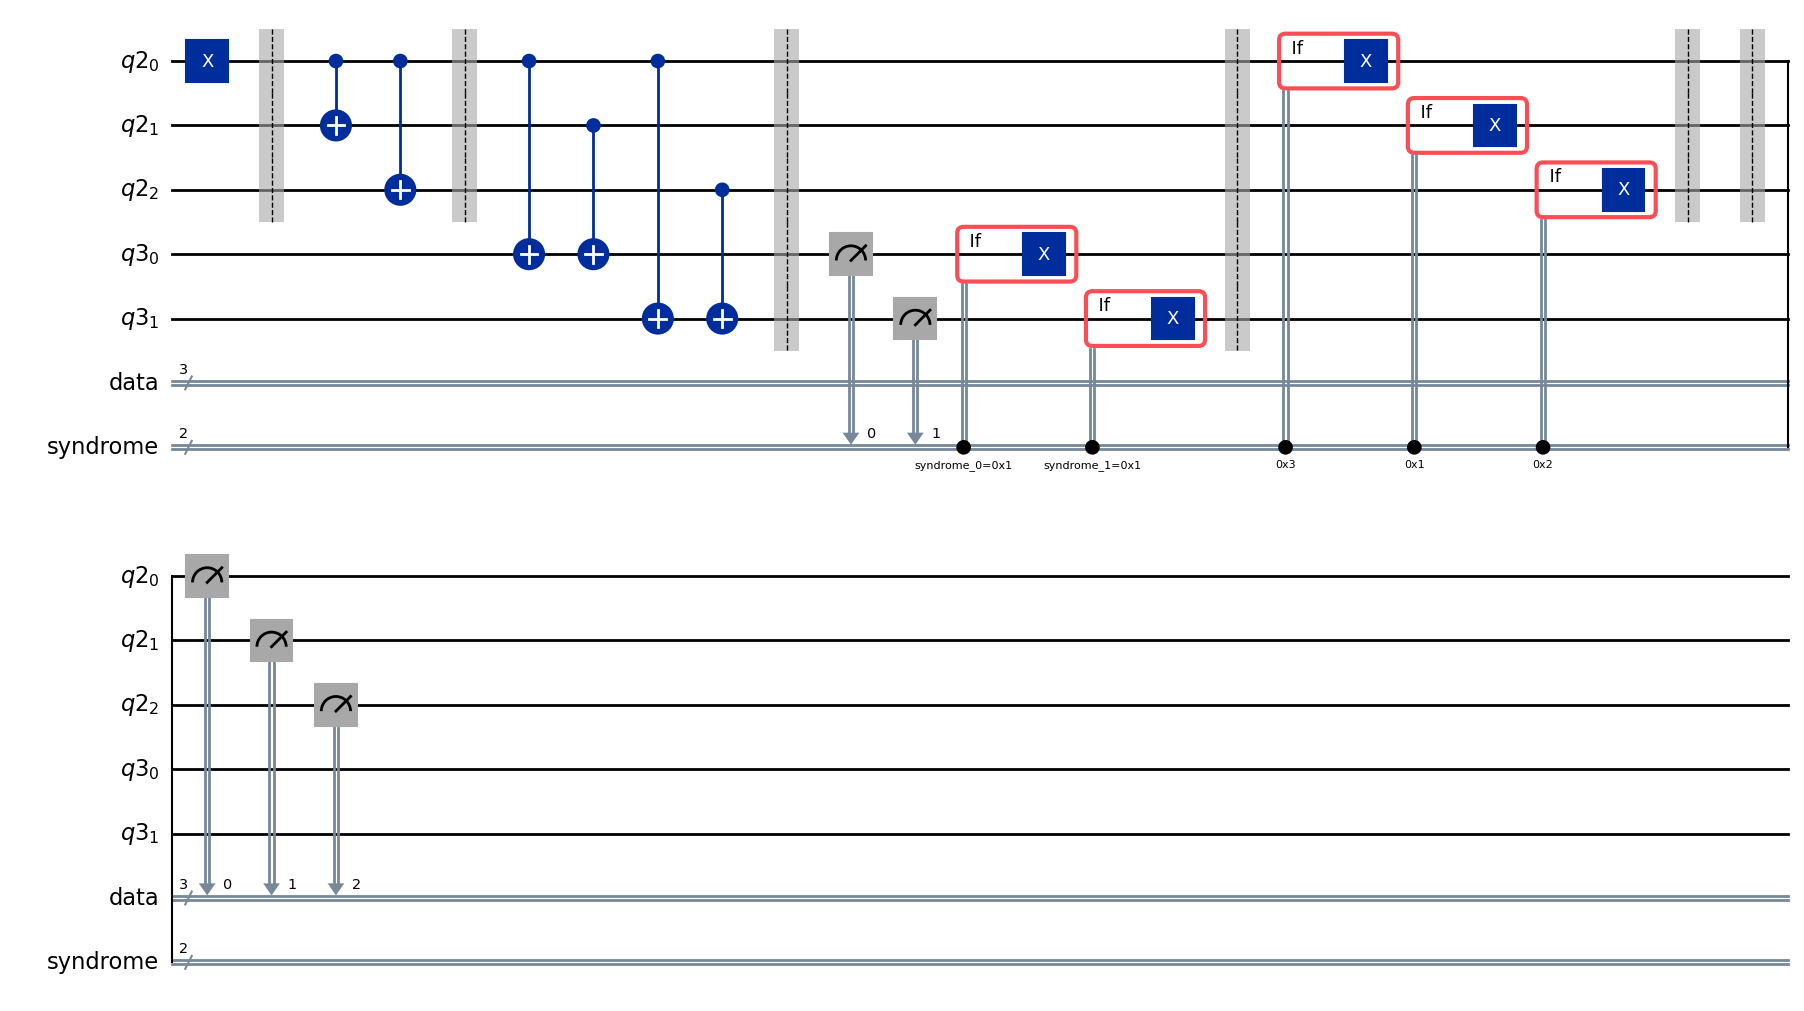

In [15]:
def build_error_correction_sequence(apply_correction: bool) -> QuantumCircuit:
    circuit = build_qc()
    circuit = initialize_qubits(circuit)
    circuit = encode_bit_flip(circuit, state_data, ancillas_data)
    circuit = measure_syndrome_bit(
        circuit, qreg_data, qreg_measure, creg_syndrome
    )
 
    if apply_correction:
        circuit = apply_correction_bit(circuit, qreg_data, creg_syndrome)
 
    circuit = apply_final_readout(circuit, qreg_data, creg_data)
    return circuit
 
 
circuit = build_error_correction_sequence(apply_correction=True)
circuit.draw(output="mpl", style="iqp")

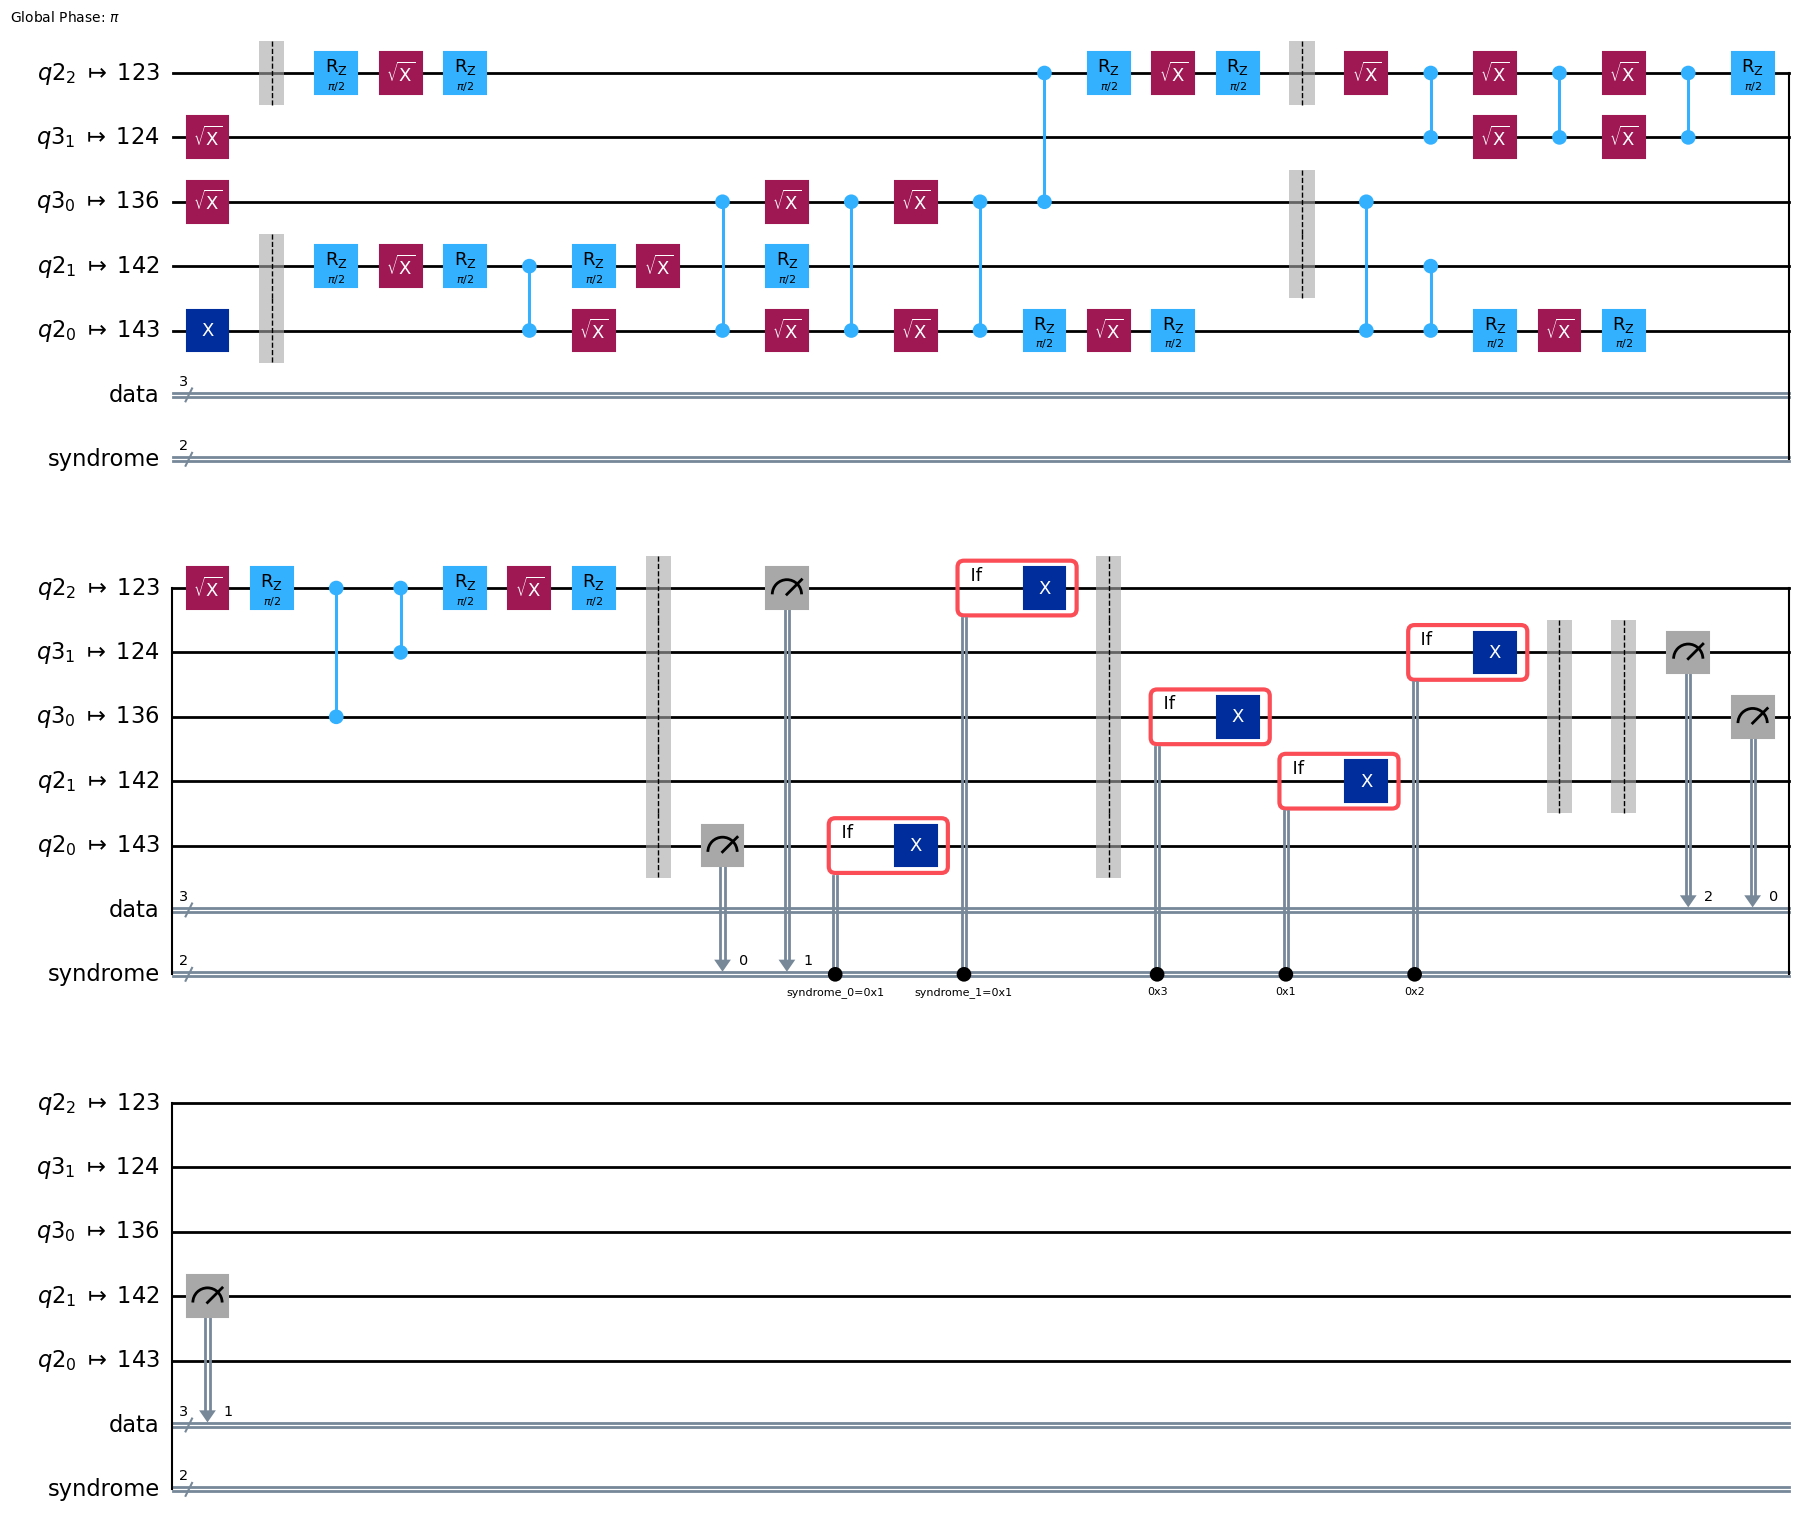

In [27]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
 
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(circuit)
 
isa_circuit.draw("mpl", style="iqp", idle_wires=False)

In [28]:
no_correction_circuit = build_error_correction_sequence(
    apply_correction=False
)
 
isa_no_correction_circuit = pm.run(no_correction_circuit)

In [ ]:
sampler_no_correction = Sampler(backend)
job_no_correction = sampler_no_correction.run(
    [isa_no_correction_circuit], shots=1000
)
result_no_correction = job_no_correction.result()[0]

: 

In [ ]:
sampler_with_correction = Sampler(backend)
 
job_with_correction = sampler_with_correction.run([isa_circuit], shots=1000)
result_with_correction = job_with_correction.result()[0]